In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [3]:
df = pd.read_csv(
r"C:\Users\Admin\OneDrive\DataScience_Internship\DataScience_week2\Task_2_Exploratory Data Analysis\Data\cleaned_ecommerce_sales.csv"
)

df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (30708, 17)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30708 entries, 0 to 30707
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            30708 non-null  str    
 1   customer_id         30708 non-null  str    
 2   product_id          30708 non-null  str    
 3   category            30708 non-null  str    
 4   price               30708 non-null  float64
 5   discount            30708 non-null  float64
 6   quantity            30708 non-null  int64  
 7   payment_method      30708 non-null  str    
 8   order_date          30708 non-null  str    
 9   delivery_time_days  30708 non-null  int64  
 10  region              30708 non-null  str    
 11  returned            30708 non-null  str    
 12  total_amount        30708 non-null  float64
 13  shipping_cost       30708 non-null  float64
 14  profit_margin       30708 non-null  float64
 15  customer_age        30708 non-null  int64  
 16  customer_gender

In [6]:
df.describe()

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,30708.000000,30708.000000,30708.000000,30708.00000,30708.000000,30708.000000,30708.000000,30708.000000
mean,69.149734,0.049997,1.410642,4.81412,81.497487,5.686843,15.597722,43.514231
std,81.338304,0.070455,0.847852,1.24257,88.958005,2.060856,21.224182,14.978437
min,1.010000,0.000000,1.000000,3.00000,0.820000,0.000000,-6.200000,18.000000
25%,14.690000,0.000000,1.000000,4.00000,17.260000,4.220000,0.910000,31.000000
50%,36.670000,0.000000,1.000000,5.00000,45.280000,5.740000,7.830000,43.000000
75%,91.320000,0.100000,1.000000,6.00000,115.042500,7.210000,22.700000,57.000000
max,548.430000,0.300000,5.000000,13.00000,391.650000,12.340000,160.550000,69.000000


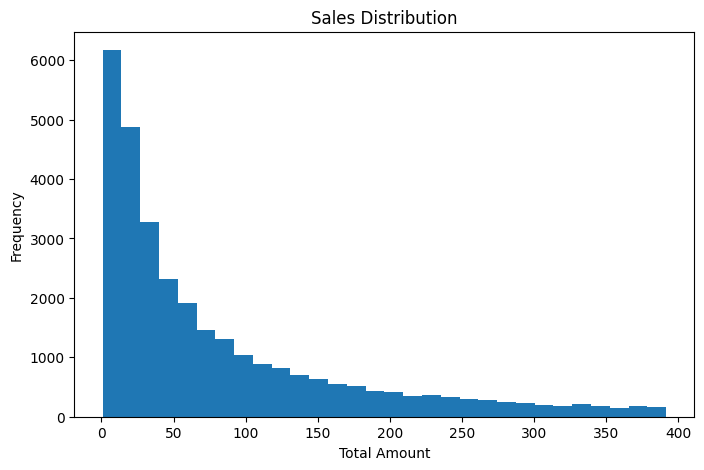

In [7]:
plt.figure(figsize=(8,5))

plt.hist(df['total_amount'], bins=30)

plt.title('Sales Distribution')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')

plt.show()

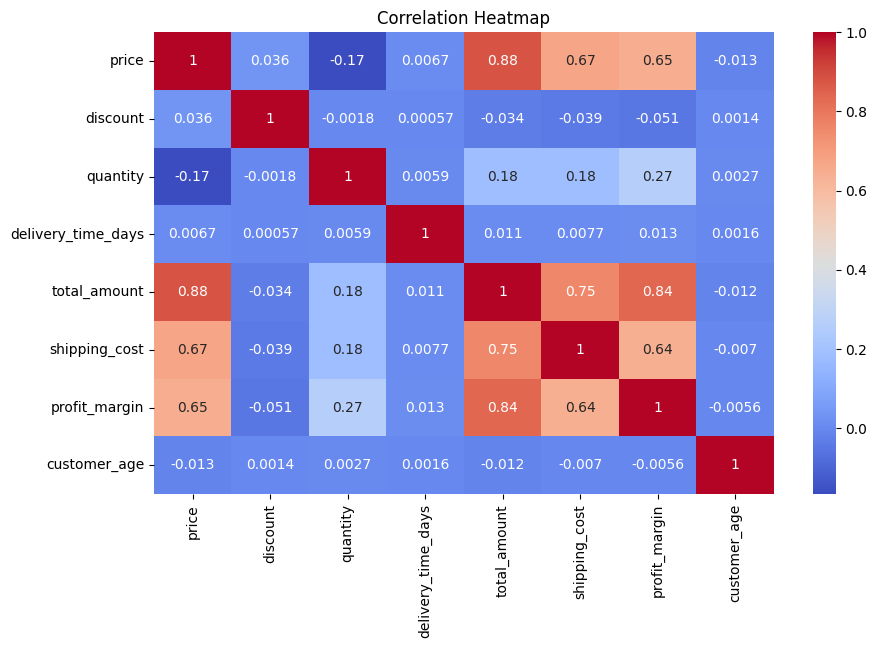

In [8]:
plt.figure(figsize=(10,6))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(
corr,
annot=True,
cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

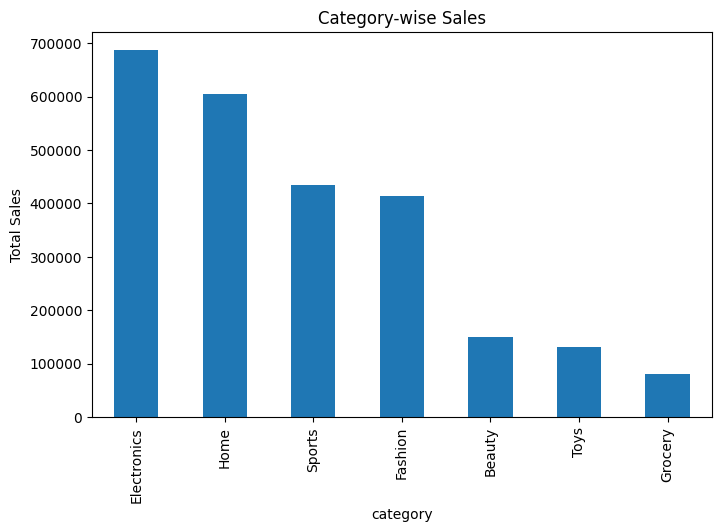

In [9]:
plt.figure(figsize=(8,5))

category_sales = df.groupby('category')['total_amount'].sum()

category_sales.sort_values(
ascending=False
).plot(kind='bar')

plt.title("Category-wise Sales")
plt.ylabel("Total Sales")

plt.show()

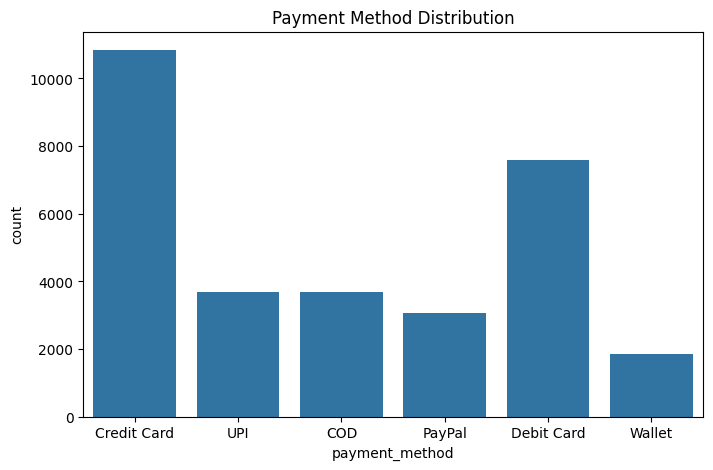

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
data=df,
x='payment_method'
)

plt.title("Payment Method Distribution")

plt.show()

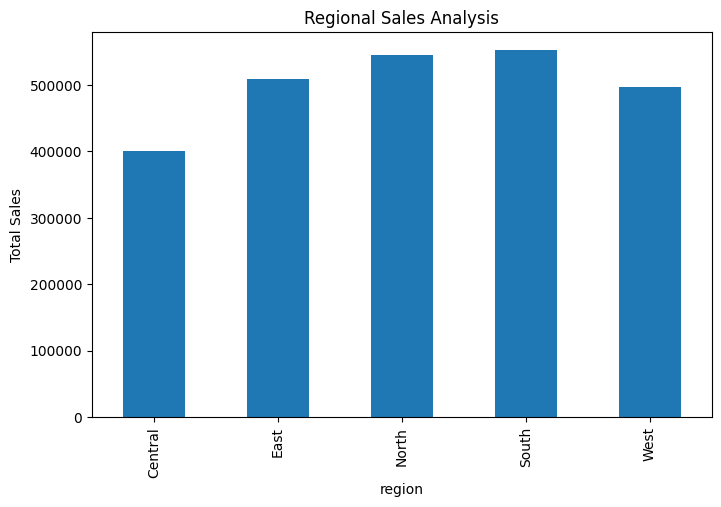

In [11]:
plt.figure(figsize=(8,5))

regional_sales = df.groupby(
'region'
)['total_amount'].sum()

regional_sales.plot(
kind='bar'
)

plt.title("Regional Sales Analysis")

plt.ylabel("Total Sales")

plt.show()

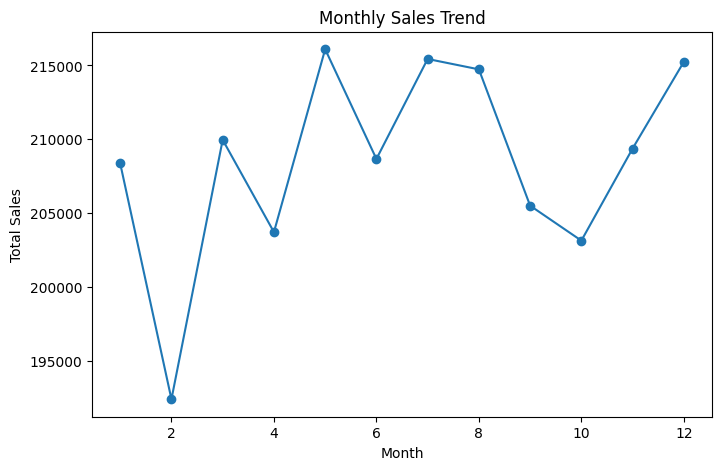

In [12]:
df['order_date'] = pd.to_datetime(
df['order_date']
)

monthly_sales = df.groupby(
df['order_date'].dt.month
)['total_amount'].sum()

plt.figure(figsize=(8,5))

monthly_sales.plot(
marker='o'
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

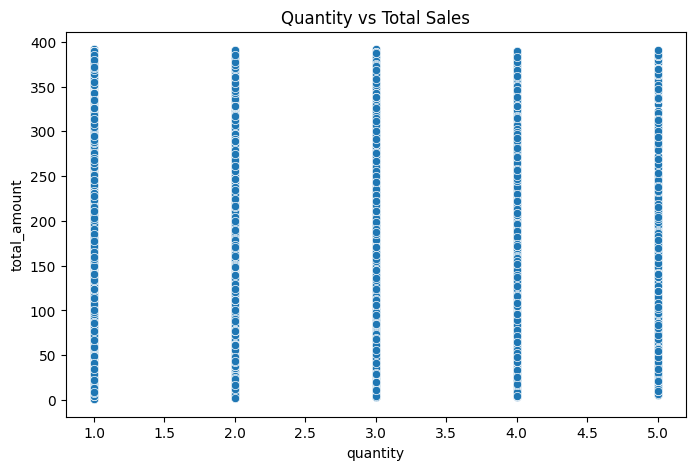

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
data=df,
x='quantity',
y='total_amount'
)

plt.title("Quantity vs Total Sales")

plt.show()